# Overview
This jupyter notebook covers the following contents:
1. Default configuration in LIBERO
2. Basic information about available LIBERO benchmarks
   - Get a dictionary of mapping from benchmark name to benchmark class
   - Check the integrity of benchmarks
   - Check the integrity of init files
   - Visualize all the init states of a task
   - Download datasets
   - Get information about a demonstration file and replay a trajectory


In [1]:
from libero.libero import benchmark, get_libero_path, set_libero_default_path
import os
from termcolor import colored

## 1. Default file paths

All the paths are retrieved from a yaml config file located at `~/.libero/config.yaml`. And the default paths are set to relative to the libero codebase.

In [2]:
benchmark_root_path = get_libero_path("benchmark_root")
init_states_default_path = get_libero_path("init_states")
datasets_default_path = get_libero_path("datasets")
bddl_files_default_path = get_libero_path("bddl_files")
print("Default benchmark root path: ", benchmark_root_path)
print("Default dataset root path: ", datasets_default_path)
print("Default bddl files root path: ", bddl_files_default_path)

Default benchmark root path:  /tmp2/hubertchang/p-jepa/LIBERO/libero/libero
Default dataset root path:  /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/../datasets
Default bddl files root path:  /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/./bddl_files


Now if you want to point your codebase to custom path, you can use `set_libero_path` function to do that. Notice that all the paths change according to `benchmark_root` value.

In [3]:
# set_libero_default_path(os.path.join(os.path.expanduser("~"), "custom_project"))
# benchmark_root_path = get_libero_path("benchmark_root")
# init_states_default_path = get_libero_path("init_states")
# datasets_default_path = get_libero_path("datasets")
# bddl_files_default_path = get_libero_path("bddl_files")
# print("Default benchmark root path: ", benchmark_root_path)
# print("Default dataset root path: ", datasets_default_path)
# print("Default bddl files root path: ", bddl_files_default_path)

# If nothing is specified in the `set_libero_default_path` function, the path will be changed back to the default path
# We will set back the path to the default path for the subsequent examples
set_libero_default_path("/tmp2/hubertchang/p-jepa/LIBERO/libero/libero")
benchmark_root_path = get_libero_path("benchmark_root")
init_states_default_path = get_libero_path("init_states")
datasets_default_path = get_libero_path("datasets")
bddl_files_default_path = get_libero_path("bddl_files")
print("Default benchmark root path: ", benchmark_root_path)
print("Default dataset root path: ", datasets_default_path)
print("Default bddl files root path: ", bddl_files_default_path)

[Warning] You are changing the default path for Libero config. This will affect all the paths in the config file.
Default benchmark root path:  /tmp2/hubertchang/p-jepa/LIBERO/libero/libero
Default dataset root path:  /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/../datasets
Default bddl files root path:  /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/./bddl_files


# 2. See available benchmarks

### 2.1 Get a dictionary of mapping from benchmark name to benchmark class

In [4]:
benchmark_dict = benchmark.get_benchmark_dict()
print(benchmark_dict)

{'libero_spatial': <class 'libero.libero.benchmark.LIBERO_SPATIAL'>, 'libero_object': <class 'libero.libero.benchmark.LIBERO_OBJECT'>, 'libero_goal': <class 'libero.libero.benchmark.LIBERO_GOAL'>, 'libero_90': <class 'libero.libero.benchmark.LIBERO_90'>, 'libero_10': <class 'libero.libero.benchmark.LIBERO_10'>, 'libero_100': <class 'libero.libero.benchmark.LIBERO_100'>}


### 2.2 Check the integrity of benchmarks

In [5]:
# initialize a benchmark
benchmark_instance = benchmark_dict["libero_10"]()
num_tasks = benchmark_instance.get_num_tasks()
# see how many tasks involved in the benchmark
print(f"{num_tasks} tasks in the benchmark {benchmark_instance.name}: ")

# Check if all the task names and their bddl file names
task_names = benchmark_instance.get_task_names()
print("The benchmark contains the following tasks:")
for i in range(num_tasks):
    task_name = task_names[i]
    task = benchmark_instance.get_task(i)
    bddl_file = os.path.join(bddl_files_default_path, task.problem_folder, task.bddl_file)
    print(f"\t {task_name}, detail definition stored in {bddl_file}")
    if not os.path.exists(bddl_file):
        print(colored(f"[error] bddl file {bddl_file} cannot be found. Check your paths", "red"))

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
10 tasks in the benchmark libero_10: 
The benchmark contains the following tasks:
	 LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket, detail definition stored in /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/./bddl_files/libero_10/LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket.bddl
	 LIVING_ROOM_SCENE2_put_both_the_cream_cheese_box_and_the_butter_in_the_basket, detail definition stored in /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/./bddl_files/libero_10/LIVING_ROOM_SCENE2_put_both_the_cream_cheese_box_and_the_butter_in_the_basket.bddl
	 KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it, detail definition stored in /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/./bddl_files/libero_10/KITCHEN_SCENE3_turn_on_the_stove_and_put_the_moka_pot_on_it.bddl
	 KITCHEN_SCENE4_put_the_black_bowl_in_the_bottom_drawer_of_the_cabinet_and_close_it, detail definition store

### 2.3 Check the integrity of init files

In [6]:
# Check if all the init states files exist for tasks
task_names = benchmark_instance.get_task_names()
print("The benchmark contains the following tasks:")
for i in range(num_tasks):
    task_name = task_names[i]
    task = benchmark_instance.get_task(i)
    init_states_path = os.path.join(init_states_default_path, task.problem_folder, task.init_states_file)
    if not os.path.exists(init_states_path):
        print(colored(f"[error] the init states {init_states_path} cannot be found. Check your paths", "red"))
print(f"An example of init file is named like this: {task.init_states_file}")

# Load torch init files
init_states = benchmark_instance.get_task_init_states(0)
# Init states in the same (num_init_rollouts, num_simulation_states)
print(init_states.shape)


The benchmark contains the following tasks:
An example of init file is named like this: KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it.pruned_init
(50, 123)


### 2.4 Visualize all the init states of a task

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/hubertchang/miniconda3/envs/vjepa2_libero/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


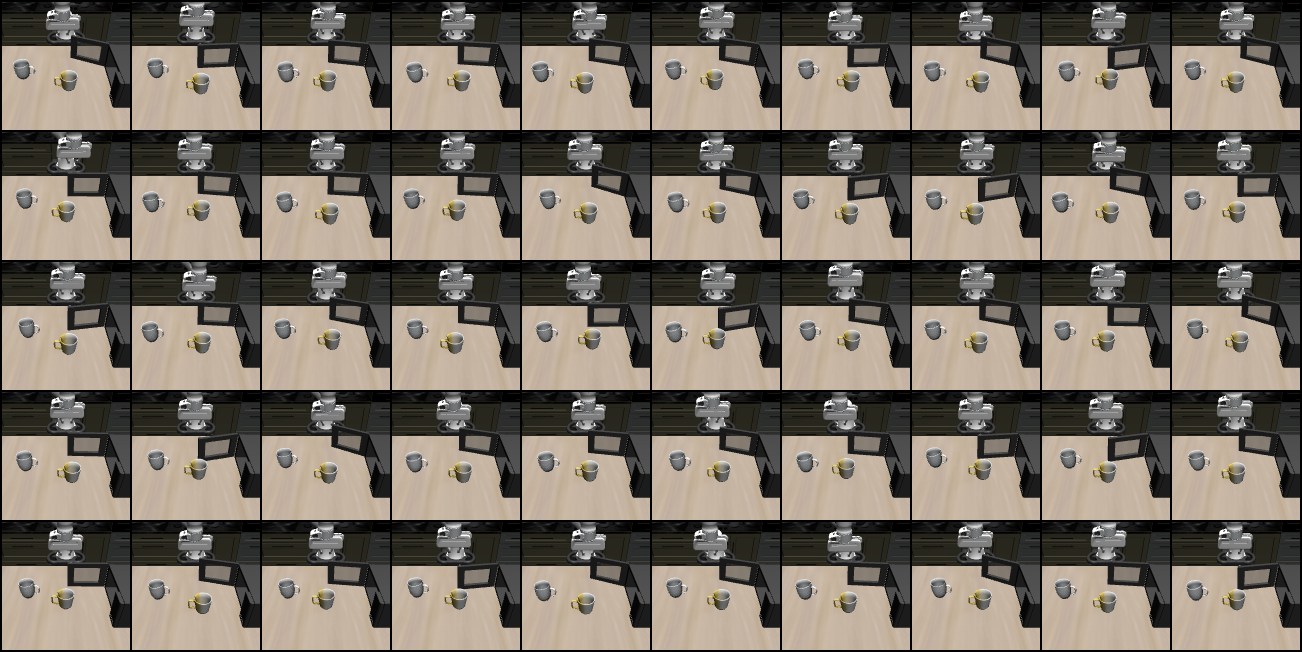

In [7]:
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import display
from PIL import Image

import torch
import torchvision

# task_id is the (task_id + 1)th task in the benchmark
task_id = 9
task = benchmark_instance.get_task(task_id)

env_args = {
    "bddl_file_name": os.path.join(bddl_files_default_path, task.problem_folder, task.bddl_file),
    "camera_heights": 128,
    "camera_widths": 128
}

env = OffScreenRenderEnv(**env_args)


init_states = benchmark_instance.get_task_init_states(task_id)

# Fix random seeds for reproducibility
env.seed(0)

def make_grid(images, nrow=8, padding=2, normalize=False, pad_value=0):
    """Make a grid of images. Make sure images is a 4D tensor in the shape of (B x C x H x W)) or a list of torch tensors."""
    grid_image = torchvision.utils.make_grid(images, nrow=nrow, padding=padding, normalize=normalize, pad_value=pad_value).permute(1, 2, 0)
    return grid_image

images = []
env.reset()
for eval_index in range(len(init_states)):
    env.set_init_state(init_states[eval_index])

    for _ in range(5):
        obs, _, _, _ = env.step([0.] * 7)
    images.append(torch.from_numpy(obs["agentview_image"]).permute(2, 0, 1))

# # images = torch.stack(images, dim=0).permute(0, 3, 1, 2)
# print(images.shape)
grid_image = make_grid(images, nrow=10, padding=2, pad_value=0)
display(Image.fromarray(grid_image.numpy()[::-1]))
env.close()

### 2.5 Download datasets

In [8]:
import libero.libero.utils.download_utils as download_utils

download_dir = get_libero_path("datasets")
datasets = "libero_spatial" # Can specify "all", "libero_goal", "libero_spatial", "libero_object", "libero_100"

libero_datasets_exist = download_utils.check_libero_dataset(download_dir=download_dir)

if not libero_datasets_exist:
    download_utils.libero_dataset_download(download_dir=download_dir, datasets=datasets)

# Check if the demo files exist
demo_files = [os.path.join(datasets_default_path, benchmark_instance.get_task_demonstration(i)) for i in range(num_tasks)]
for demo_file in demo_files:
    if not os.path.exists(demo_file):
        print(colored(f"[error] demo file {demo_file} cannot be found. Check your paths", "red"))

[X] Dataset libero_object is complete
[X] Dataset libero_goal is complete
[X] Dataset libero_spatial is complete
[X] Dataset libero_10 is complete
[X] Dataset libero_90 is complete


### 2.6 Get information about a demonstration file and replay a trajectory

In [9]:
import h5py
from libero.libero.utils.dataset_utils import get_dataset_info
from IPython.display import HTML
import imageio

example_demo_file = demo_files[9]
# Print the dataset info. We have a standalone script for doing the same thing available at `scripts/get_dataset_info.py`
get_dataset_info(example_demo_file)

with h5py.File(example_demo_file, "r") as f:
    images = f["data/demo_0/obs/agentview_rgb"][()]

video_writer = imageio.get_writer("output.mp4", fps=60)
for image in images:
    video_writer.append_data(image[::-1])
video_writer.close()

HTML("""
    <video width="640" height="480" controls>
        <source src="output.mp4" type="video/mp4">
    </video>
    <script>
        var video = document.getElementsByTagName('video')[0];
        video.playbackRate = 2.0; // Increase the playback speed to 2x
        </script>    
""")


total transitions: 15232
total trajectories: 50
traj length mean: 304.64
traj length std: 46.59989699559432
traj length min: 224
traj length max: 449
action min: -1.0
action max: 1.0
language instruction: put the yellow and white mug in the microwave and close it

==== Filter Keys ====
no filter keys


==== Env Meta ====
{
    "type": 1,
    "env_name": "Libero_Kitchen_Tabletop_Manipulation",
    "problem_name": "libero_kitchen_tabletop_manipulation",
    "bddl_file": "chiliocosm/bddl_files/libero_100/KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it.bddl",
    "env_kwargs": {
        "robots": [
            "Panda"
        ],
        "controller_configs": {
            "type": "OSC_POSE",
            "input_max": 1,
            "input_min": -1,
            "output_max": [
                0.05,
                0.05,
                0.05,
                0.5,
                0.5,
                0.5
            ],
            "output_min": [
                -0.0

### 2.6.2 Re-render the same demonstration states at higher resolution (256x256)

The original demo stores 128x128 RGB observations. Here we use the recorded simulator `states` from the same task/demo and re-render them in a 256x256 offscreen environment.

In [10]:
import json
import os
from pathlib import Path

import h5py
import imageio

from libero.libero import get_libero_path
from libero.libero.envs import OffScreenRenderEnv
from IPython.display import HTML


def resolve_bddl_path(bddl_path_from_meta):
    """Resolve bddl path from dataset metadata to an existing local file."""
    # 1) Already absolute / directly valid
    if os.path.exists(bddl_path_from_meta):
        return bddl_path_from_meta

    # 2) Relative to benchmark root (covers many local setups)
    benchmark_root = get_libero_path("benchmark_root")
    candidate = os.path.join(benchmark_root, bddl_path_from_meta)
    if os.path.exists(candidate):
        return candidate

    # 3) Relative to configured bddl_files root
    #    Metadata often contains prefixes like "chiliocosm/bddl_files/..."
    if "bddl_files/" in bddl_path_from_meta:
        rel_under_bddl = bddl_path_from_meta.split("bddl_files/", 1)[1]
        candidate = os.path.join(get_libero_path("bddl_files"), rel_under_bddl)
        if os.path.exists(candidate):
            return candidate

    # 4) Fallback: find by basename anywhere under bddl_files
    bddl_root = Path(get_libero_path("bddl_files"))
    basename = Path(bddl_path_from_meta).name
    matches = list(bddl_root.rglob(basename))
    if matches:
        return str(matches[0])

    raise FileNotFoundError(
        f"Could not resolve BDDL file from metadata path: {bddl_path_from_meta}"
    )


example_demo_id = "demo_0"
target_h, target_w = 256, 256
output_video = "output_256.mp4"

with h5py.File(example_demo_file, "r") as f:
    env_meta = json.loads(f["data"].attrs["env_args"])
    env_kwargs = dict(env_meta["env_kwargs"])
    states = f[f"data/{example_demo_id}/states"][()]

resolved_bddl_file = resolve_bddl_path(env_kwargs["bddl_file_name"])
print(f"Using BDDL file: {resolved_bddl_file}")

# Build a clean render config from dataset metadata.
# Avoid forwarding controller_configs directly to OffScreenRenderEnv
# because it would conflict with internally constructed controller configs.

# Choose your preferred view. If unavailable in the loaded model,
# we automatically fall back to sideview.
preferred_camera = "droidview"
fallback_camera = "sideview"

base_camera_names = list(dict.fromkeys(env_kwargs.get("camera_names", []) + [fallback_camera]))

render_env_kwargs = {
    "bddl_file_name": resolved_bddl_file,
    "robots": env_kwargs.get("robots", ["Panda"]),
    "camera_heights": target_h,
    "camera_widths": target_w,
    "camera_depths": False,
    "use_camera_obs": True,
    "has_renderer": False,
    "has_offscreen_renderer": True,
    "ignore_done": True,
    "control_freq": env_kwargs.get("control_freq", 20),
}

camera_key = f"{preferred_camera}_image"
try:
    # Try preferred custom camera first
    env = OffScreenRenderEnv(
        **render_env_kwargs,
        camera_names=list(dict.fromkeys(base_camera_names + [preferred_camera])),
    )
    env.reset()
    print(f"Using preferred camera: {preferred_camera}")
except ValueError as err:
    # Typical failure: camera does not exist in this loaded model
    if preferred_camera in str(err):
        print(
            f"Preferred camera '{preferred_camera}' is not available in this model. "
            f"Falling back to '{fallback_camera}'."
        )
        env = OffScreenRenderEnv(**render_env_kwargs, camera_names=base_camera_names)
        env.reset()
        camera_key = f"{fallback_camera}_image"
    else:
        raise

rendered_images = []
for step_id, state in enumerate(states):
    obs = env.set_init_state(state)
    if camera_key not in obs:
        available_keys = sorted([k for k in obs.keys() if k.endswith("_image")])
        raise KeyError(
            f"{camera_key} not found in observation. "
            f"Available image keys: {available_keys}"
        )
    rendered_images.append(obs[camera_key][::-1])

env.close()

video_writer = imageio.get_writer(output_video, fps=60)
for image in rendered_images:
    video_writer.append_data(image)
video_writer.close()

print(f"Rendered {len(rendered_images)} frames to {output_video} at {target_h}x{target_w}.")

HTML(f"""
    <video width="640" height="480" controls>
        <source src=\"{output_video}\" type=\"video/mp4\">
    </video>
    <script>
        var video = document.getElementsByTagName('video')[0];
        video.playbackRate = 1.0;
    </script>
""")

Using BDDL file: /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/bddl_files/libero_10/KITCHEN_SCENE6_put_the_yellow_and_white_mug_in_the_microwave_and_close_it.bddl
Using preferred camera: droidview
Rendered 329 frames to output_256.mp4 at 256x256.


### 2.6.3 Save one droidview trajectory video for every task in the benchmark

This rerenders `demo_0` for each task from stored simulator states, and writes one MP4 per task to `notebooks/videos`.

In [ ]:
import json
import os
from pathlib import Path

import h5py
import imageio

from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv


def resolve_bddl_path(bddl_path_from_meta):
    if os.path.exists(bddl_path_from_meta):
        return bddl_path_from_meta

    benchmark_root = get_libero_path("benchmark_root")
    candidate = os.path.join(benchmark_root, bddl_path_from_meta)
    if os.path.exists(candidate):
        return candidate

    if "bddl_files/" in bddl_path_from_meta:
        rel_under_bddl = bddl_path_from_meta.split("bddl_files/", 1)[1]
        candidate = os.path.join(get_libero_path("bddl_files"), rel_under_bddl)
        if os.path.exists(candidate):
            return candidate

    bddl_root = Path(get_libero_path("bddl_files"))
    basename = Path(bddl_path_from_meta).name
    matches = list(bddl_root.rglob(basename))
    if matches:
        return str(matches[0])

    raise FileNotFoundError(
        f"Could not resolve BDDL file from metadata path: {bddl_path_from_meta}"
    )


# Self-contained setup so this cell can run independently.
benchmark_name = "libero_spatial" #options: libero_10, libero_90, libero_object, libero_goal, libero_spatial
benchmark_instance = benchmark.get_benchmark_dict()[benchmark_name]()
datasets_default_path = get_libero_path("datasets")

camera_name = "droidview"
camera_key = f"{camera_name}_image"
fps = 60
video_h, video_w = 256, 256
output_dir = f"/home/hubertchang/p-jepa/MPC/lerobot-libero/notebooks/videos/{benchmark_name}"
os.makedirs(output_dir, exist_ok=True)

num_tasks = benchmark_instance.get_num_tasks()
print(f"Rendering {num_tasks} tasks from benchmark: {benchmark_instance.name}")
print(f"Dataset root: {datasets_default_path}")
print(f"Saving videos to: {output_dir}")

failed_tasks = []

for task_id in range(num_tasks):
    task = benchmark_instance.get_task(task_id)
    demo_file = os.path.join(
        datasets_default_path, benchmark_instance.get_task_demonstration(task_id)
    )

    if not os.path.exists(demo_file):
        msg = f"Demo file not found: {demo_file}"
        failed_tasks.append((task_id, task.name, msg))
        print(f"[{task_id:03d}] FAILED ({task.name}): {msg}")
        continue

    with h5py.File(demo_file, "r") as f:
        env_meta = json.loads(f["data"].attrs["env_args"])
        env_kwargs = dict(env_meta["env_kwargs"])
        states = f["data/demo_0/states"][()]

    env = None
    try:
        # Prefer benchmark-provided BDDL for this task; metadata can be stale
        # (e.g. old libero_100_debug paths).
        task_bddl_file = os.path.join(
            get_libero_path("bddl_files"), task.problem_folder, task.bddl_file
        )
        if os.path.exists(task_bddl_file):
            bddl_file = task_bddl_file
        else:
            bddl_file = resolve_bddl_path(env_kwargs["bddl_file_name"])

        print(f"[{task_id:03d}] using BDDL: {bddl_file}")

        requested_cameras = list(
            dict.fromkeys(env_kwargs.get("camera_names", []) + [camera_name])
        )

        render_env_kwargs = {
            "bddl_file_name": bddl_file,
            "robots": env_kwargs.get("robots", ["Panda"]),
            "camera_names": requested_cameras,
            "camera_heights": video_h,
            "camera_widths": video_w,
            "camera_depths": False,
            "use_camera_obs": True,
            "has_renderer": False,
            "has_offscreen_renderer": True,
            "ignore_done": True,
            "control_freq": env_kwargs.get("control_freq", 20),
        }

        env = OffScreenRenderEnv(**render_env_kwargs)
        env.reset()

        rendered_images = []
        for state in states:
            obs = env.set_init_state(state)
            if camera_key not in obs:
                available_keys = sorted([k for k in obs.keys() if k.endswith("_image")])
                raise KeyError(
                    f"{camera_key} not found. Available image keys: {available_keys}"
                )
            rendered_images.append(obs[camera_key][::-1])

        safe_name = "".join([c if c.isalnum() or c in "-_" else "_" for c in task.name])
        video_path = os.path.join(output_dir, f"{task_id:03d}_{safe_name}_{camera_name}.mp4")

        video_writer = imageio.get_writer(video_path, fps=fps)
        for image in rendered_images:
            video_writer.append_data(image)
        video_writer.close()

        print(f"[{task_id:03d}] saved {video_path} ({len(rendered_images)} frames)")

    except Exception as e:
        failed_tasks.append((task_id, task.name, str(e)))
        print(f"[{task_id:03d}] FAILED ({task.name}): {e}")

    finally:
        if env is not None:
            env.close()

print(f"Done. Success: {num_tasks - len(failed_tasks)}/{num_tasks}")
if failed_tasks:
    print("Failed tasks:")
    for task_id, task_name, msg in failed_tasks:
        print(f"  - [{task_id:03d}] {task_name}: {msg}")

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Rendering 10 tasks from benchmark: libero_spatial
Dataset root: /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/../datasets
Saving videos to: /home/hubertchang/p-jepa/MPC/lerobot-libero/notebooks/videos/libero_spatial
[000] using BDDL: /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/./bddl_files/libero_spatial/pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate.bddl
[000] saved /home/hubertchang/p-jepa/MPC/lerobot-libero/notebooks/videos/libero_spatial/000_pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate_droidview.mp4 (98 frames)
[001] using BDDL: /tmp2/hubertchang/p-jepa/LIBERO/libero/libero/./bddl_files/libero_spatial/pick_up_the_black_bowl_next_to_the_ramekin_and_place_it_on_the_plate.bddl
[001] saved /home/hubertchang/p-jepa/MPC/lerobot-libero/notebooks/videos/libero_spatial/001_pick_up_the_black_bowl_next_to_the_ramekin_and_place_it_on_the_plate_droidview.mp4 (152 f

### 2.7 Concate multiple datasets for multit-task training

In [12]:
from torch.utils.data import ConcatDataset, Dataset
from libero.lifelong.datasets import get_dataset, SequenceVLDataset

num_tasks = benchmark_instance.get_num_tasks()
print(f"Number of tasks in the benchmark {benchmark_instance.name}: {num_tasks}")

# manip_datasets = []
# for demo_file in demo_files:
#     task_i_dataset, shape_meta = get_dataset(
#             dataset_path=os.path.join(cfg.folder,
#                                         benchmark.get_task_demonstration(i)),
#             obs_modality=cfg.data.obs.modality,
#             initialize_obs_utils=(i==0),
#             seq_len=cfg.data.seq_len)    
#     manip_datasets.append()

# concat_dataset = ConcatDataset([get_dataset(demo_file) for demo_file in demo_files])

Number of tasks in the benchmark libero_90: 90


### 2.8 Create datasets for Experience Replay algorithm

In the algorithm of ER, we need to sample data from both dataset of the current task and data from previous experiences. To this end, a specific implementation is needed (`TruncatedSequenceDataset`).